In [2]:
import pandas as pd
from google.colab import drive
drive.mount('/drive')
df = pd.read_csv('/drive/MyDrive/creditcard.csv')

Mounted at /drive


In [3]:
from sklearn.model_selection import train_test_split

X = df[["V17","V14","V12","V10","V16","V3","V7","V11","V4","V18"]]
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Define instantiated models (not classes) with reasonable params
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "svm": SVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost" : XGBClassifier(eval_metric="logloss", random_state=42),
    "LightGBM" : lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Containers for metrics
names = []
acc_list = []
precision_list = []
recall_list = []
f1_list = []

# Fit, predict, and collect metrics
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    names.append(name)
    acc_list.append(accuracy_score(y_test, y_pred))
    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))

# Assemble results into a DataFrame
final_result = pd.DataFrame({
    "Model": names,
    "Accuracy": acc_list,
    "Precision": precision_list,
    "Recall": recall_list,
    "f1": f1_list
})

print(f"Final result is: \n {final_result}")


[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037916 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339
Final result is: 
                  Model  Accuracy  Precision    Recall        f1
0  Logistic Regression  0.999105   0.821918  0.612245  0.701754
1                  svm  0.999456   0.958904  0.714286  0.818713
2        Random Forest  0.999684   0.954545  0.857143  0.903226
3              XGBoost  0.999350   0.814433  0.806122  0.810256
4             LightGBM  0.994382   0.198370  0.744898  0.313305


In [ ]:

display(final_result)

,Model,Accuracy,Precision,Recall,f1
0,Logistic Regression,0.999105,0.821918,0.612245,0.701754
1,svm,0.999456,0.958904,0.714286,0.818713
2,Random Forest,0.999684,0.954545,0.857143,0.903226
3,XGBoost,0.999350,0.814433,0.806122,0.810256
4,LightGBM,0.994382,0.198370,0.744898,0.313305


In [ ]:
best_model = final_result.sort_values(by="f1", ascending=False).iloc[0]
display(best_model)

,2
Model,Random Forest
Accuracy,0.999684
Precision,0.954545
Recall,0.857143
f1,0.903226


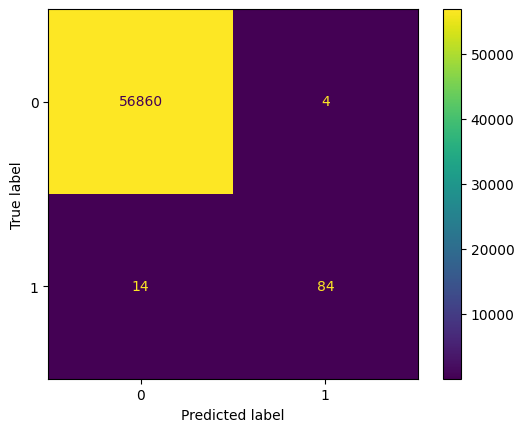

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model_pred = models[best_model["Model"]].predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, best_model_pred)

/tmp/ipykernel_3426/1397125118.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


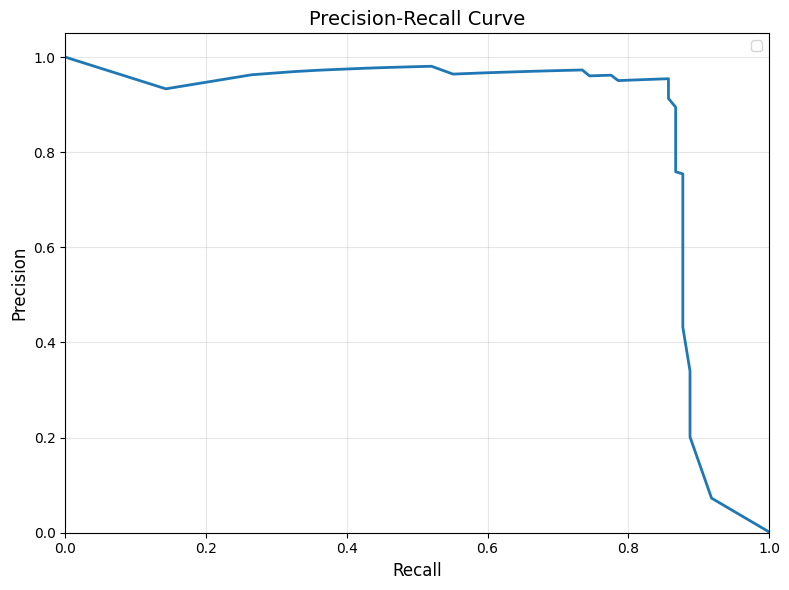

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_score = models[best_model["Model"]].predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_score)

ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8, 6))

plt.plot(recall, precision, linewidth=2)

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve", fontsize=14)

plt.xlim([0, 1])
plt.ylim([0, 1.05])

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

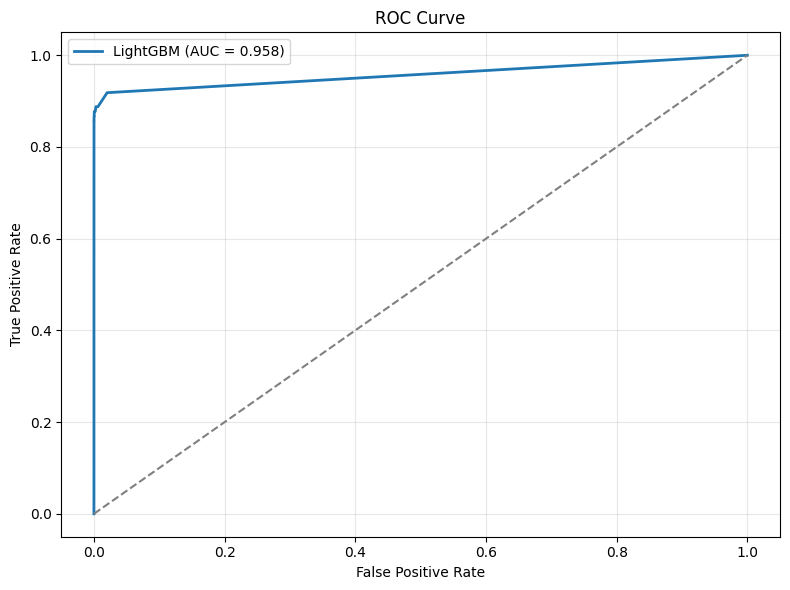

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_score = models[best_model["Model"]].predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_score)

auc = roc_auc_score(y_test, y_score)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, linewidth=2,
         label=f'LightGBM (AUC = {auc:.3f})')


plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

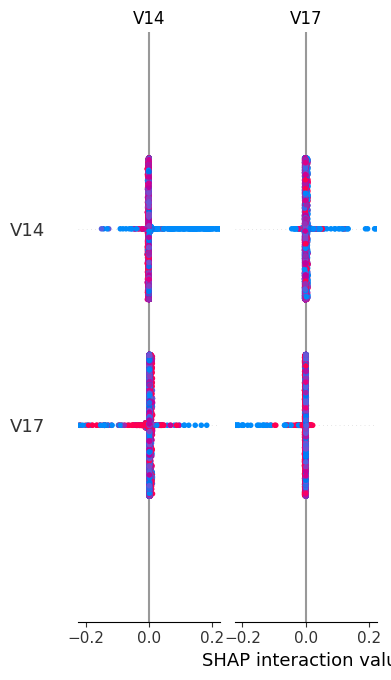

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(models[best_model["Model"]])
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


In [4]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Define instantiated models (not classes) with reasonable params
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "svm": SVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost" : XGBClassifier(eval_metric="logloss", random_state=42),
    "LightGBM" : lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Containers for metrics
names = []
acc_list = []
precision_list = []
recall_list = []
f1_list = []

# Fit, predict, and collect metrics
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    names.append(name)
    acc_list.append(accuracy_score(y_test, y_pred))
    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))

# Assemble results into a DataFrame
final_result = pd.DataFrame({
    "Model": names,
    "Accuracy": acc_list,
    "Precision": precision_list,
    "Recall": recall_list,
    "f1": f1_list
})

print(f"Final result is: \n {final_result}")


[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.050267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Final result is: 
                  Model  Accuracy  Precision    Recall        f1
0  Logistic Regression  0.970735   0.051970  0.928571  0.098432
1                  svm  0.975001   0.058000  0.887755  0.108886
2        Random Forest  0.999263   0.764151  0.826531  0.794118
3              XGBoost  0.997718   0.420792  0.867347  0.566667
4             LightGBM  0.994084   0.210654  0.887755  0.340509


  0%|          | 0/50 [00:00<?, ?it/s]

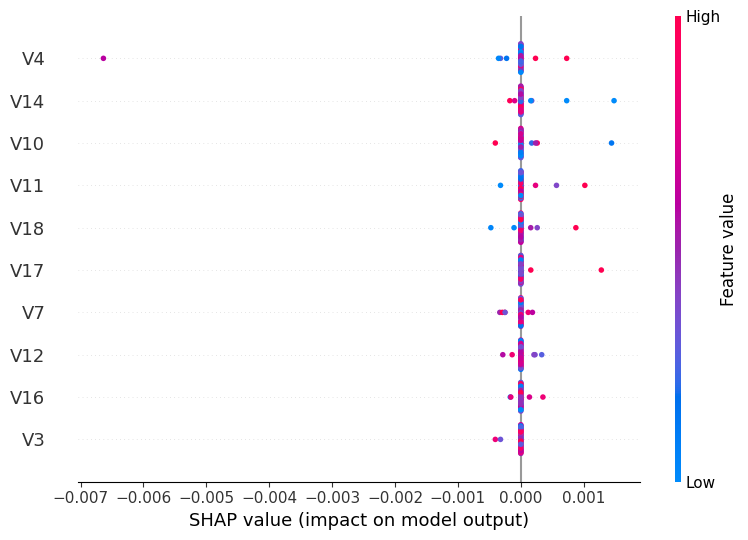

In [6]:
import shap

explainer = shap.KernelExplainer(models["Random Forest"].predict, X_train[:100])
shap_values = explainer.shap_values(X_test[:50])
shap.summary_plot(shap_values, X_test[:50])